## Регрессия для CC50

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]
CSV_PATH = PROJECT_ROOT / Path("./data/reg_cc50.csv").resolve()
print(CSV_PATH)

E:\Study\projects\coursework_classic_ml\data\reg_cc50.csv


In [3]:
df = pd.read_csv(CSV_PATH)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,153,154,155,156,157,158,159,160,161,target
0,-1.609209,1.315234,1.274257,-0.900747,1.055290,0.0,1.389704,-1.566113,-2.076304,-0.731655,...,-0.110152,-0.09525,-0.031623,-0.031623,-0.234082,0.0,-0.274204,4.361269,-0.083918,175.482382
1,-1.733165,1.698809,1.616019,-0.717860,1.234754,0.0,1.184451,-1.782336,-2.224521,-0.708822,...,-0.110152,-0.09525,-0.031623,-0.031623,-0.234082,0.0,-0.274204,4.361269,-0.083918,5.402819
2,-1.831528,1.717840,1.639180,-1.432643,0.997105,0.0,1.053951,-1.099982,-2.409791,-0.653210,...,-0.110152,-0.09525,-0.031623,-0.031623,-0.234082,0.0,-0.274204,4.361269,-0.083918,161.142320
3,-1.608793,1.326268,1.281687,-1.049655,0.971554,0.0,1.389704,-1.566113,-2.168300,-0.731812,...,-0.110152,-0.09525,-0.031623,-0.031623,-0.234082,0.0,-0.274204,4.361269,-0.083918,107.855654
4,-1.601971,0.843212,1.030148,-0.854751,0.551671,0.0,1.739635,-1.365744,-2.254164,-0.730327,...,-0.110152,-0.09525,-0.031623,-0.031623,-0.234082,0.0,-0.274204,-0.229295,-0.083918,139.270991


In [4]:
X_ic50 = df.drop(columns=['target'])
y_ic50 = df['target']
X_train, X_test, y_train, y_test = train_test_split(X_ic50, y_ic50, test_size=0.1, random_state=42)


In [5]:
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 7, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': [0.5, 'sqrt', 'log2']
}
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search_rf.fit(X_train, y_train)
y_pred_train = grid_search_rf.best_estimator_.predict(X_train)
y_pred_test = grid_search_rf.best_estimator_.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

retraining = abs(train_r2 - test_r2)

print(f"\n=== RandomForestRegressor производительность модели CC50 ===")
print(f"Обучение R2: {train_r2:.4f}")
print(f"Тест R2:  {test_r2:.4f}")
print(f"Обучение MSE: {train_mse:.4f}")
print(f"Тест MSE:  {test_mse:.4f}")
print(f"\nПоказатель переобучения: {retraining:.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

=== RandomForestRegressor производительность модели CC50 ===
Обучение R2: 0.8217
Тест R2:  0.6539
Обучение MSE: 70499.6790
Тест MSE:  196405.6038

Показатель переобучения: 0.1678


RandomForestRegressor показывает хорошую производительность, есть небольшое переобучение но, если будет больше данных переобучение будет меньше

<Axes: xlabel='importance', ylabel='feature'>

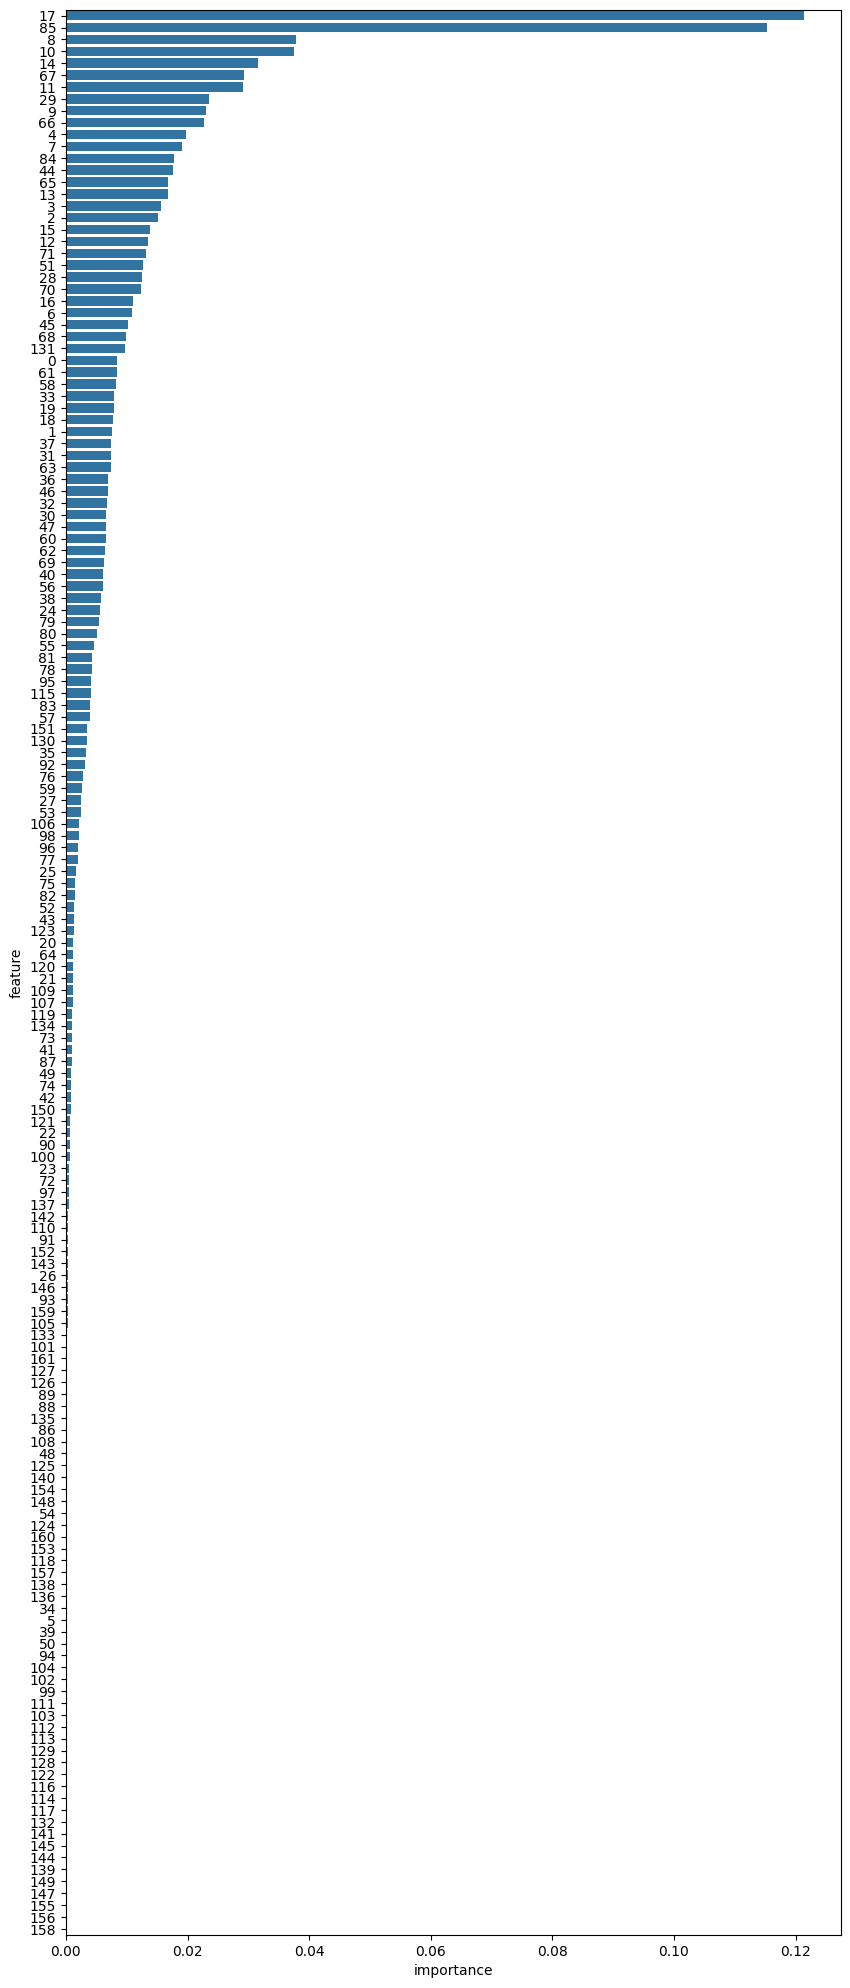

In [6]:
fi = grid_search_rf.best_estimator_.feature_importances_
df_fi = pd.DataFrame({'feature': X_ic50.columns, 'importance': fi})
df_fi = df_fi.sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 25))
sns.barplot(data=df_fi, x='importance', y='feature')

на графике показывает важность признаков, какие признаки дают больший вклад в объясненную дисперсию, а какие меньше. Но так как это медицинские данные нельзя просто признаки удалять

In [7]:
ridge = Ridge(random_state=42)
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search_ridge.fit(X_train, y_train)
y_pred_train_ridge = grid_search_ridge.best_estimator_.predict(X_train)
y_pred_test_ridge = grid_search_ridge.best_estimator_.predict(X_test)


train_r2_ridge = r2_score(y_train, y_pred_train_ridge)
test_r2_ridge = r2_score(y_test, y_pred_test_ridge)
train_mse_ridge = mean_squared_error(y_train, y_pred_train_ridge)
test_mse_ridge = mean_squared_error(y_test, y_pred_test_ridge)

retraining_ridge = abs(train_r2_ridge - test_r2_ridge)

print(f"\n===  производительность модели CC50 ===")
print(f"Обучение R2: {train_r2_ridge:.4f}")
print(f"Тест R2:  {test_r2_ridge:.4f}")
print(f"Обучение MSE: {train_mse_ridge:.4f}")
print(f"Тест MSE:  {test_mse_ridge:.4f}")
print(f"\nПоказатель переобучения: {retraining_ridge:.4f}")
print(f"\nЛучшие параметры: {grid_search_ridge.best_estimator_}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits

===  производительность модели CC50 ===
Обучение R2: 0.5652
Тест R2:  0.5494
Обучение MSE: 171944.9985
Тест MSE:  255722.0961

Показатель переобучения: 0.0158

Лучшие параметры: Ridge(alpha=10, random_state=42)


у Ridge переобучения нет, объясняет лучше среднего. Это средний результат для задачи. С учетом низкого переобучения то модель обладает обобщающей способностью и является стабильной. Высокий MSE есть выбросы

In [8]:
lasso = Lasso(random_state=42)
param_grid_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid_lasso,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search_lasso.fit(X_train, y_train)
y_pred_train_lasso = grid_search_lasso.best_estimator_.predict(X_train)
y_pred_test_lasso = grid_search_lasso.best_estimator_.predict(X_test)


train_r2_lasso = r2_score(y_train, y_pred_train_lasso)
test_r2_lasso = r2_score(y_test, y_pred_test_lasso)
train_mse_lasso = mean_squared_error(y_train, y_pred_train_lasso)
test_mse_lasso = mean_squared_error(y_test, y_pred_test_lasso)

retraining_lasso = abs(train_r2_lasso - test_r2_lasso)

print(f"\n=== Lasso производительность модели CC50 ===")
print(f"Обучение R2: {train_r2_lasso:.4f}")
print(f"Тест R2:  {test_r2_lasso:.4f}")
print(f"Обучение MSE: {train_mse_lasso:.4f}")
print(f"Тест MSE:  {test_mse_lasso:.4f}")
print(f"\nПоказатель переобучения: {retraining_lasso:.4f}")
print(f"\nЛучшие параметры: {grid_search_lasso.best_estimator_}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits

=== Lasso производительность модели CC50 ===
Обучение R2: 0.5685
Тест R2:  0.5384
Обучение MSE: 170653.0072
Тест MSE:  261939.4928

Показатель переобучения: 0.0300

Лучшие параметры: Lasso(alpha=1, random_state=42)


c:\Users\arayd\anaconda3\envs\gpu_cuda\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.427e+04, tolerance: 3.559e+04
  model = cd_fast.enet_coordinate_descent(


у Lasso переобучения нет, объясняет лучше среднего. Это средний результат для задачи. С учетом низкого переобучения то модель обладает обобщающей способностью и является стабильной. Высокий MSE есть выбросы

In [9]:
xgb = XGBRegressor(random_state = 42, device="cuda", tree_method="hist")
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 7, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'alpha': [0, 0.1, 1],
    'lambda': [1, 5, 10]
}
grid_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=1,
    verbose=1
)
grid_search_xgb.fit(X_train, y_train)


y_pred_train_xgb = grid_search_xgb.best_estimator_.predict(X_train)
y_pred_test_xgb = grid_search_xgb.best_estimator_.predict(X_test)

train_r2_xgb = r2_score(y_train, y_pred_train_xgb)
test_r2_xgb = r2_score(y_test, y_pred_test_xgb)
train_mse_xgb = mean_squared_error(y_train, y_pred_train_xgb)
test_mse_xgb = mean_squared_error(y_test, y_pred_test_xgb)

retraining_xgb = abs(train_r2_xgb - test_r2_xgb)


print(f"\n=== XGBRegressor производительность модели CC50 ===")
print(f"Обучение R2: {train_r2_xgb:.4f}")
print(f"Тест R2:  {test_r2_xgb:.4f}")
print(f"Обучение MSE: {train_mse_xgb:.4f}")
print(f"Тест MSE:  {test_mse_xgb:.4f}")
print(f"\nПоказатель переобучения: {retraining_xgb:.4f}")
print(f"\nЛучшие параметры: {grid_search_xgb.best_params_}")


Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\arayd\anaconda3\envs\gpu_cuda\lib\site-packages\xgboost\core.py:158: UserWarning: [16:23:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



=== XGBRegressor производительность модели CC50 ===
Обучение R2: 0.8024
Тест R2:  0.6816
Обучение MSE: 78138.9136
Тест MSE:  180719.4332

Показатель переобучения: 0.1208

Лучшие параметры: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'lambda': 10, 'colsample_bytree': 0.7, 'alpha': 1}


XGBRegressor показал хорошую производительность, заметно лучше чем линейные модели, хоть есть и небольшое переобучение, предпологаю что если бы было больше данных, можно добиться лучших показателей и на тесте  

In [10]:
df_metrics_train = pd.DataFrame({
    'Model': ['RandomForest', 'Ridge', 'Lasso', 'XGBoost'],
    'R2': [train_r2, train_r2_ridge, train_r2_lasso, train_r2_xgb],
    'MSE': [train_mse, train_mse_ridge, train_mse_lasso, train_mse_xgb]
})

df_metrics_test = pd.DataFrame({
    'Model': ['RandomForest', 'Ridge', 'Lasso', 'XGBoost'],
    'R2': [test_r2, test_r2_ridge, test_r2_lasso, test_r2_xgb],
    'MSE': [test_mse, test_mse_ridge, test_mse_lasso, test_mse_xgb],
    'RETRAINING': [retraining, retraining_ridge, retraining_lasso, retraining_xgb]
})

C:\Users\arayd\AppData\Local\Temp\ipykernel_23660\862235921.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


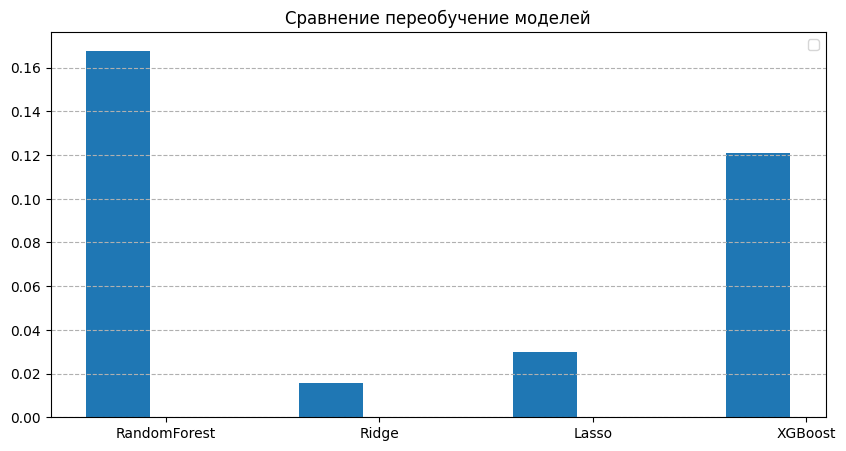

In [11]:
plt.figure(figsize=(10, 5))
width = 0.3
x = np.arange(len(df_metrics_test['Model']))
plt.bar(x - 0.75 * width, df_metrics_test['RETRAINING'], width)
plt.xticks(x, df_metrics_test['Model'])
plt.legend()
plt.grid(axis='y',linestyle= '--')
plt.title('Сравнение переобучение моделей')
plt.show()

у линейных моделей переобучение на уровне погрешности, у ансамблей есть небольшое переобучение

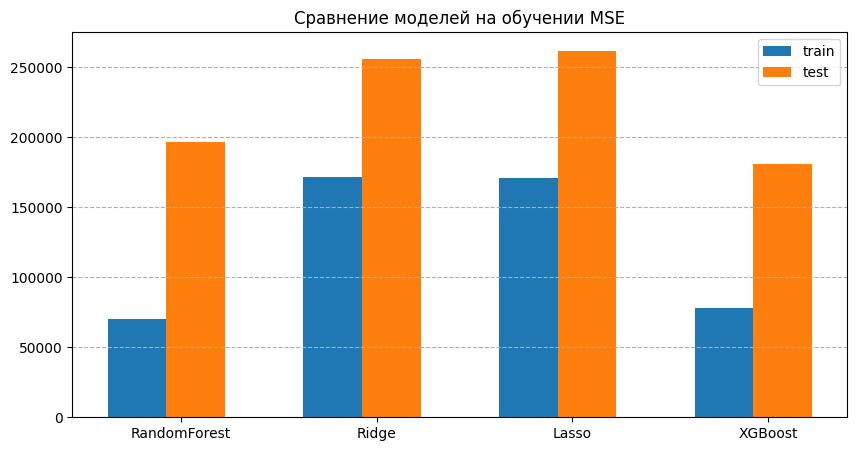

In [12]:
plt.figure(figsize=(10, 5))
width = 0.3
x = np.arange(len(df_metrics_train['Model']))
plt.bar(x - 0.75 * width, df_metrics_train['MSE'], width, label='train')
plt.bar(x + 0.25 * width, df_metrics_test['MSE'], width, label='test')
plt.xticks(x, df_metrics_train['Model'])
plt.legend()
plt.grid(axis='y',linestyle= '--')
plt.title('Сравнение моделей на обучении MSE')
plt.show()

высокий MSE так как много выбросов

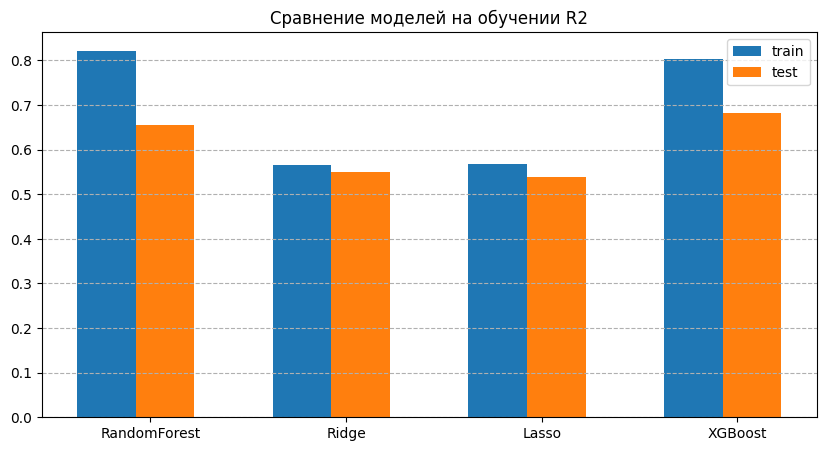

In [13]:
plt.figure(figsize=(10, 5))
width = 0.3
x = np.arange(len(df_metrics_train['Model']))
plt.bar(x - 0.75 * width, df_metrics_train['R2'], width, label='train')
plt.bar(x + 0.25 * width, df_metrics_test['R2'], width, label='test')
plt.xticks(x, df_metrics_train['Model'])
plt.legend()
plt.grid(axis='y',linestyle= '--')
plt.title('Сравнение моделей на обучении R2')
plt.show()

Так как шумные данные и ненормольно распределенные, линейные модели показали себя хуже, предсказывают на новых данных лучше чем среднее, зато нет переобучения. Ансамбли показали себя лучше. Лучше всего производительность показала модель XGBRegressor, у нее хороший R2 и меньше переобучение.Имя больше данных производительность моделей можно увеличить. Я такого колличества данных модели показали хорошие результаты